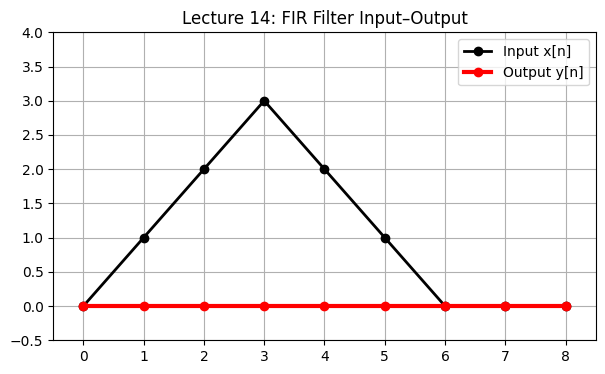

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# -----------------------------
# Lecture 14: FIR Filter Input / Output Animation
# Same style as Lecture 9
# -----------------------------

# Input signal (finite-length)
x = np.array([0, 1, 2, 3, 2, 1, 0, 0, 0])
N = len(x)

# FIR filter coefficients
b = np.array([0.25, 0.5, 0.25])
M = len(b)

# FIR filtering (causal convolution)
y = np.zeros(N)
for n in range(N):
    for k in range(M):
        if n - k >= 0:
            y[n] += b[k] * x[n - k]

n = np.arange(N)

# Plot setup
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(-0.5, max(max(x), max(y)) + 1)
ax.grid(True)
ax.set_title("Lecture 14: FIR Filter Input–Output")

# Plot input signal (static)
ax.plot(n, x, 'ko-', lw=2, label="Input x[n]")

# Animated output signal
y_line, = ax.plot([], [], 'ro-', lw=3, label="Output y[n]")

ax.legend(loc="upper right")

# -----------------------------
# Animation update (Lecture 9 style)
# -----------------------------
def update(frame):
    y_display = np.zeros(N)
    y_display[:frame + 1] = y[:frame + 1]

    y_line.set_data(n, y_display)
    return (y_line,)

anim = FuncAnimation(fig, update, frames=N, interval=700)

HTML(anim.to_jshtml())

Top curve (black): input signal x[n]x[n]x[n]
Bottom curve (red): FIR filter output y[n]y[n]y[n], appearing over time
Output starts at zero and builds causally, as an FIR filter must